# **1. Install & Import Libraries**

In [ ]:
!pip install pandas matplotlib joblib statsmodels scikit-learn > /dev/null

In [ ]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [ ]:
warnings.filterwarnings('ignore')

# **2. Data Loading & Cleaning**

In [ ]:
try:
    file_path = '/content/household_power_consumption.csv'
    print(f"\n[STATUS] Membaca dataset dari: {file_path}")

    df = pd.read_csv(file_path, sep=',', low_memory=False)

    print("\n[SAMPLE DATA] 5 data pertama:")
    display(df.head())

    print("\n[INFORMASI DATA]")
    print(f"- Total Records: {len(df):,}")
    print(f"- Columns: {list(df.columns)}")
    print(f"- Memory Usage: {df.memory_usage().sum()/1024/1024:.2f} MB")

    print("\n[PROCESS] Memulai data cleaning:")
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df = df.set_index('datetime')
    df = df.drop(columns=['Date', 'Time', 'index'])
    print("- Kolom datetime berhasil dibuat...")

    print("\n[SAMPLE CLEANED DATA]:")
    display(df.head())

    numeric_cols = ['Global_active_power', 'Global_reactive_power',
                    'Voltage', 'Global_intensity',
                    'Sub_metering_1', 'Sub_metering_2']

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['Sub_metering_3'] = df['Sub_metering_3'].fillna(0)
    df = df.fillna(df.mean())

    print("\n[SUMMARY] Data bersih:")
    print(f"- Shape: {df.shape}")
    print(f"- Null Values: {df.isnull().sum().sum()}")

    print("\n[INFO FINAL]:")
    display(df.info())
except Exception as e:
    print(f"\n[ERROR] {str(e)}")
    raise


[STATUS] Membaca dataset dari: /content/household_power_consumption.csv

[SAMPLE DATA] 5 data pertama:


,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0



[INFORMASI DATA]
- Total Records: 260,640
- Columns: ['index', 'Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
- Memory Usage: 19.89 MB

[PROCESS] Memulai data cleaning:
- Kolom datetime berhasil dibuat...

[SAMPLE CLEANED DATA]:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2007-01-01 00:00:00,2.58,0.136,241.97,10.6,0,0,0.0
2007-01-01 00:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2007-01-01 00:02:00,2.55,0.1,241.64,10.4,0,0,0.0
2007-01-01 00:03:00,2.55,0.1,241.71,10.4,0,0,0.0
2007-01-01 00:04:00,2.554,0.1,241.98,10.4,0,0,0.0



[SUMMARY] Data bersih:
- Shape: (260640, 7)
- Null Values: 0

[INFO FINAL]:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 260640 entries, 2007-01-01 00:00:00 to 2007-06-30 23:59:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Global_active_power    260640 non-null  float64
 1   Global_reactive_power  260640 non-null  float64
 2   Voltage                260640 non-null  float64
 3   Global_intensity       260640 non-null  float64
 4   Sub_metering_1         260640 non-null  float64
 5   Sub_metering_2         260640 non-null  float64
 6   Sub_metering_3         260640 non-null  float64
dtypes: float64(7)
memory usage: 15.9 MB


None

# **3. Resampling Data**

In [ ]:
print("\n[PROCESS] Resampling ke per-jam...")
df_per_jam = df.resample('h').sum()
df_per_jam.to_csv('data_listrik_bersih_per_jam.csv')

print("[SUCCESS] Resampling selesai:")
print(f"- Jumlah baris baru: {len(df_per_jam)}")
print(f"- File tersimpan: 'data_listrik_bersih_per_jam.csv'")

print("\n[SAMPLE DATA]:")
display(df_per_jam.head())


[PROCESS] Resampling ke per-jam...
[SUCCESS] Resampling selesai:
- Jumlah baris baru: 4344
- File tersimpan: 'data_listrik_bersih_per_jam.csv'

[SAMPLE DATA]:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2007-01-01 00:00:00,153.038,6.768,14481.68,631.8,0.0,35.0,0.0
2007-01-01 01:00:00,151.404,4.298,14465.79,626.6,0.0,0.0,0.0
2007-01-01 02:00:00,154.940,6.400,14592.01,632.4,0.0,20.0,0.0
2007-01-01 03:00:00,152.500,5.406,14595.94,624.0,0.0,16.0,0.0
2007-01-01 04:00:00,148.544,5.290,14547.37,606.6,0.0,0.0,0.0


# **4. Exploratory Data Analysis**


[VISUALIZATION] Membuat plot konsumsi listrik...


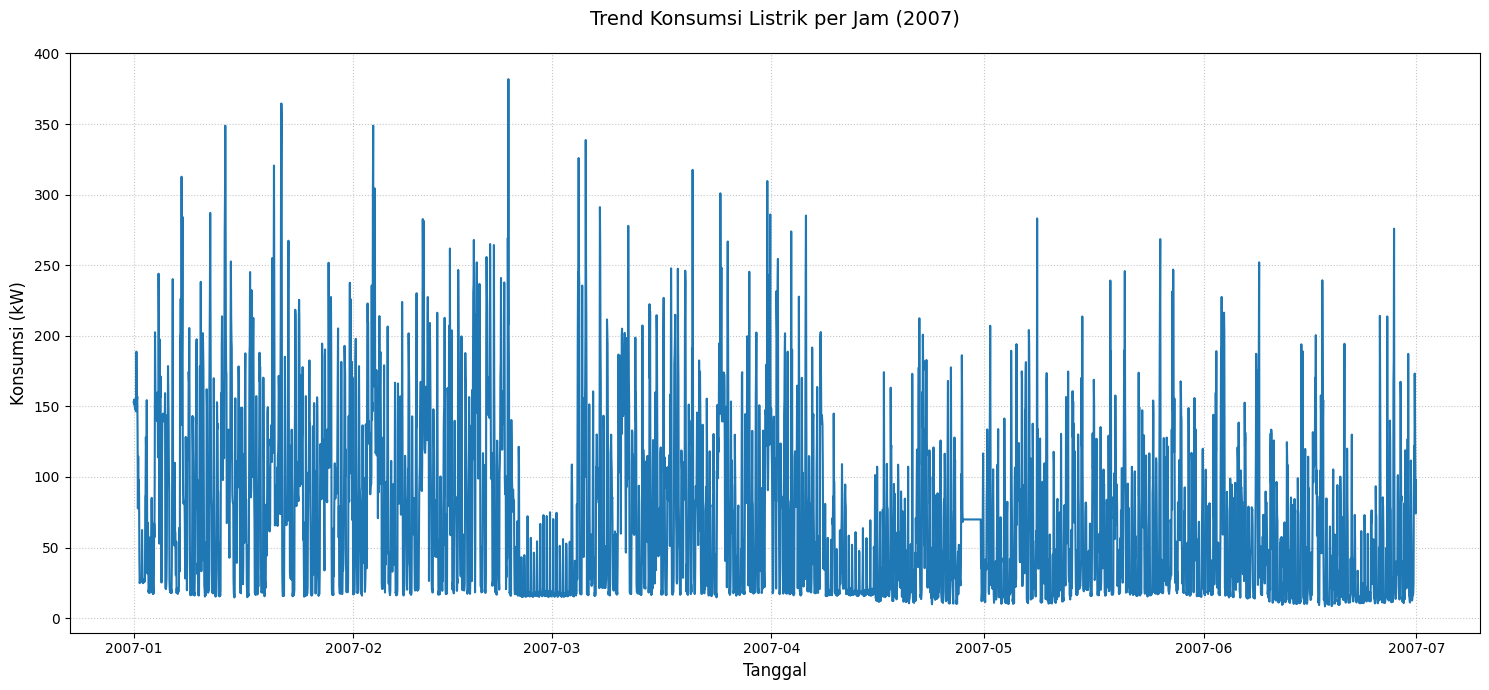

In [ ]:
print("\n[VISUALIZATION] Membuat plot konsumsi listrik...")
plt.figure(figsize=(15, 7))
plt.plot(df_per_jam.index, df_per_jam['Global_active_power'],
         label='Konsumsi Listrik (kW)', linewidth=1.5, color='#1f77b4')
plt.title('Trend Konsumsi Listrik per Jam (2007)', pad=20, fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Konsumsi (kW)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# **5. Model Development**

In [ ]:
data_untuk_model = df_per_jam['Global_active_power']
train_size = int(len(data_untuk_model) * 0.8)
train_data, test_data = data_untuk_model[0:train_size], data_untuk_model[train_size:]

print(f"\n[DATA SPLITTING]")
print(f"- Training: {len(train_data)} baris ({train_size/len(data_untuk_model):.0%})")
print(f"- Testing:  {len(test_data)} baris ({1-train_size/len(data_untuk_model):.0%})")


[DATA SPLITTING]
- Training: 3475 baris (80%)
- Testing:  869 baris (20%)


In [ ]:
print("\n[MODEL TRAINING] Melatih SARIMA...")
model_sarima = SARIMAX(train_data,
                       order=(5, 1, 0),
                       seasonal_order=(1, 0, 0, 24))
model_sarima_fit = model_sarima.fit(disp=False)

print("\n[MODEL SUMMARY]")
print(model_sarima_fit.summary())


[MODEL TRAINING] Melatih SARIMA...

[MODEL SUMMARY]
                                     SARIMAX Results                                      
Dep. Variable:                Global_active_power   No. Observations:                 3475
Model:             SARIMAX(5, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -17920.276
Date:                            Mon, 16 Jun 2025   AIC                          35854.552
Time:                                    15:55:24   BIC                          35897.623
Sample:                                01-01-2007   HQIC                         35869.929
                                     - 05-25-2007                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1693      0.013    -13.214      0.000      -

# **6. Model Evaluation**

In [ ]:
predictions = model_sarima_fit.forecast(steps=len(test_data))
rmse = np.sqrt(mean_squared_error(test_data, predictions))

print(f"\n[PERFORMANCE] RMSE: {rmse:.4f}")


[PERFORMANCE] RMSE: 60.2393



[VISUALIZATION] Actual vs Predicted


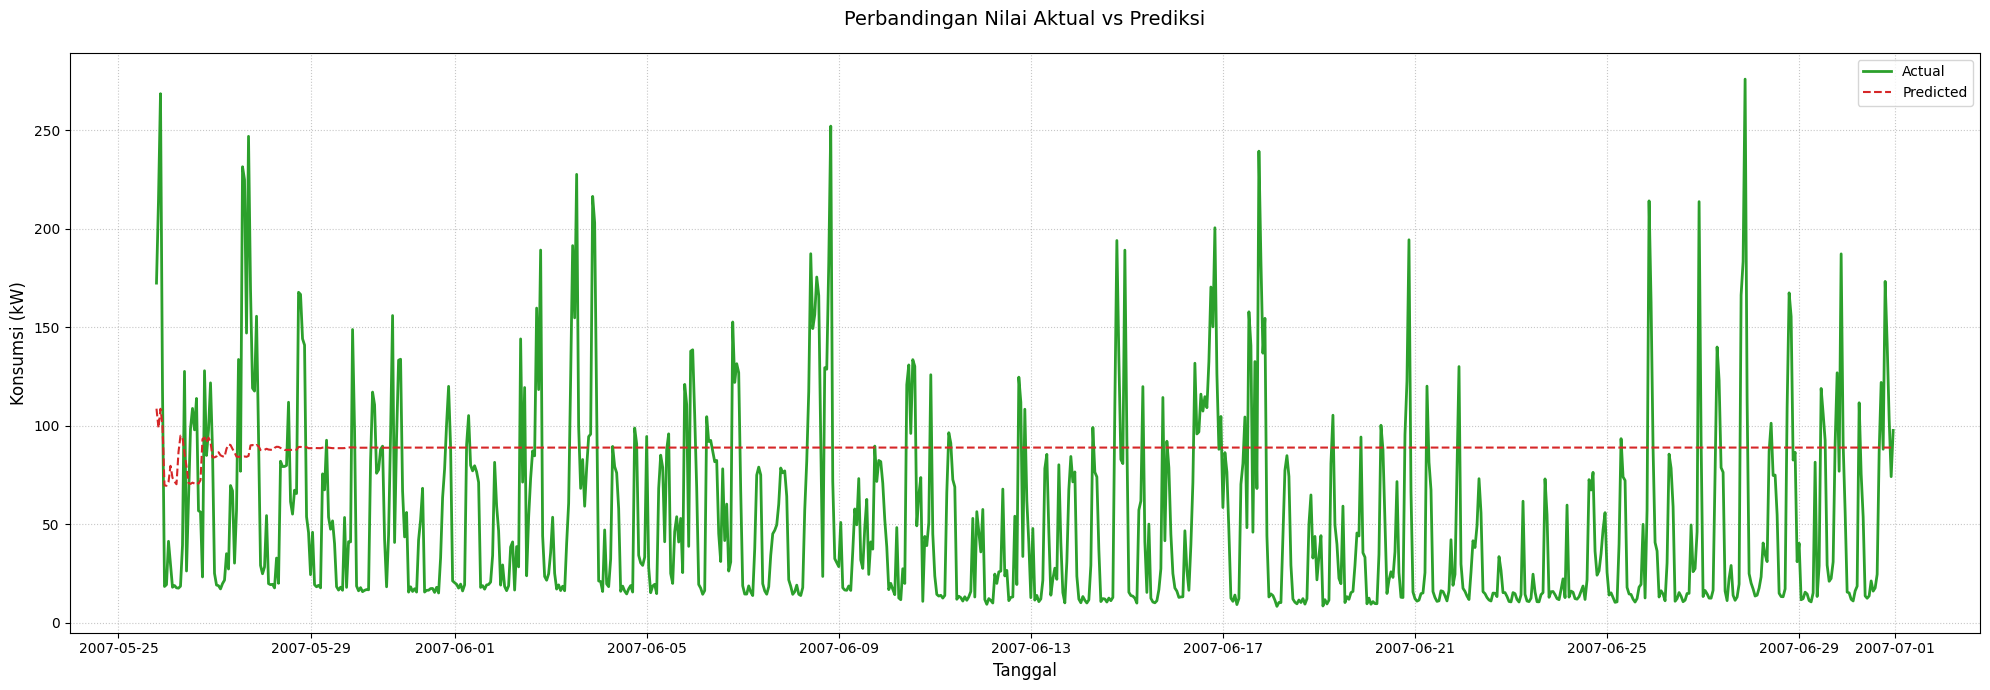

In [ ]:
print("\n[VISUALIZATION] Actual vs Predicted")
plt.figure(figsize=(20, 7))
plt.plot(test_data.index, test_data,
         label='Actual', linewidth=2, color='#2ca02c')
plt.plot(test_data.index, predictions,
         label='Predicted', linestyle='--', color='#d62728')
plt.title('Perbandingan Nilai Aktual vs Prediksi', pad=20, fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Konsumsi (kW)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# **7. Save Model**

In [ ]:
nama_file_model = 'model_prediksi_listrik.pkl'
joblib.dump(model_sarima_fit, nama_file_model)
print(f"\n[SUCCESS] Model tersimpan sebagai: '{nama_file_model}'")


[SUCCESS] Model tersimpan sebagai: 'model_prediksi_listrik.pkl'
